# 20260701_ALU_x — measured spindle angle + torque from force_0/force_1

Computes a measured spindle angular position `phi(t)` directly from the machine
channel's absolute spindle encoder (`axis0_positionact`, confirmed by inspection to
be hardware-wrapped to `[0, 360)` degrees at 250 Hz — no RPM integration needed),
then projects `force_0`/`force_1` (`Fx`/`Fy`, 20 kHz) onto the tangential direction
at that angle to get a cutting-torque proxy `Mc(t)`. Uses the two new
`MillingSignalUtils` methods added to `py/src/kienzle_utils.py`:
`phi_from_encoder` and `spindle_torque`.

**Data**: `data/converted/20260701_ALU_x/{machine_0,force_0,force_1}_lev008_ALU_y_raw.parquet`
— these filenames carry over the old `lev008_ALU_y` suffix from a copy-pasted
notebook, but their `time` columns confirm they hold today's (2026-07-01) data.

**Not used here**: `lev008_ALU_y_cut_summary_tagged.parquet` and
`nc_command_log_lev008_ALU_y.parquet` in this same folder. They were carried over
from the *old* `20260630` dataset by that same copy-pasted notebook (its cut
timestamps are literally `2026-06-30`) and do not describe this recording, so this
notebook detects its own analysis window instead of relying on them.

**Known limitations** (see the notes cell at the end): the phase offset between the
encoder zero and the force sensor's X axis (`phi0_offset` in `spindle_torque`) is
not yet calibrated, and `force_0`/`force_1` are raw ADC counts, not newtons — so
`Mc` here is a torque-shaped proxy for QA, not a calibrated physical torque.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "py" / "src"))
from kienzle_utils import MillingSignalUtils as MSU

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 2.3.3, numpy 1.26.4


In [2]:
OUTPUT_DIR = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260701_ALU_x")

mdf = pd.read_parquet(OUTPUT_DIR / "machine_0_lev008_ALU_y_raw.parquet")
f0  = pd.read_parquet(OUTPUT_DIR / "force_0_lev008_ALU_y_raw.parquet")   # Fx
f1  = pd.read_parquet(OUTPUT_DIR / "force_1_lev008_ALU_y_raw.parquet")  # Fy

print(f"machine_0: {mdf.shape}, {mdf['block_idx'].nunique()} blocks")
print(f"force_0:   {f0.shape}, force_1: {f1.shape}")
print(f"machine time range: {mdf['time'].min()} -> {mdf['time'].max()}")
print(f"force_0 time range: {f0['time'].min()} -> {f0['time'].max()}")

machine_0: (27000, 171), 108 blocks
force_0:   (105, 20010), force_1: (106, 20010)
machine time range: 2026-07-01 08:48:27.820000+00:00 -> 2026-07-01 10:34:30.820000+00:00
force_0 time range: 2026-07-01 08:50:26.820000+00:00 -> 2026-07-01 10:34:30.820000+00:00


## 1 - Reconstruct per-sample timestamps

Same block-end convention used by the existing axon-logger notebooks: a block's
`time` marks its **last** sample, and samples within a block are evenly spaced at
`1/fs`. `machine_0` is long-format (one row per sample, `sample_idx` present) at
250 Hz; `force_0`/`force_1` are wide-format (one row per block, columns
`s00000..s19999`) at 20 kHz — the two need slightly different reconstruction code.

Gotcha confirmed while prototyping this: `time` is stored as `datetime64[us]`, so
`.astype("int64")` gives **microseconds** since epoch, not nanoseconds — using the
wrong unit silently produces a wildly wrong (but plausible-looking) timeline.

In [3]:
def add_sample_time(df: pd.DataFrame, fs: float) -> pd.DataFrame:
    """Reconstruct per-sample timestamps for long-format (machine_0) data."""
    df = df.sort_values(["block_idx", "sample_idx"]).reset_index(drop=True)
    n_samples = df.groupby("block_idx")["sample_idx"].transform("max") + 1
    step_us = 1e6 / fs
    block_end_us = df["time"].astype("int64")  # datetime64[us] -> microseconds since epoch
    offset_us = (n_samples - 1 - df["sample_idx"]).to_numpy() * step_us
    sample_time_us = block_end_us.to_numpy() - offset_us.astype("int64")
    df["sample_time"] = pd.to_datetime(sample_time_us, unit="us", utc=True)
    return df.sort_values("sample_time").reset_index(drop=True)


mdf = add_sample_time(mdf, fs=250.0)
t0 = mdf["sample_time"].iloc[0]
mdf["t_s"] = (mdf["sample_time"] - t0).dt.total_seconds()
print(f"t0 = {t0}")

t0 = 2026-07-01 08:48:26.824000+00:00


## 2 - Pick an analysis window

The recording has real logging gaps (the acquisition pauses between passes/idle
periods, up to tens of seconds). `phi_from_encoder` linearly interpolates the
unwrapped encoder angle, which is only meaningful *within* a contiguous run of
machine samples — interpolating across a multi-second gap would silently smear the
angle across dead time. So: find the longest contiguous, spinning (`|rpm| > 1000`)
stretch of `machine_0` and use that as the demo window (a full pipeline over the
whole recording would instead chunk by contiguous run, e.g. per detected cut).

In [4]:
def largest_contiguous_run(t_s: np.ndarray, expected_dt: float, tol: float = 0.5):
    """Index range (inclusive) of the longest run without a logging gap."""
    dt = np.diff(t_s)
    gap = dt > expected_dt * (1 + tol)
    boundaries = np.flatnonzero(gap)
    starts = np.r_[0, boundaries + 1]
    ends = np.r_[boundaries, len(t_s) - 1]
    k = np.argmax(ends - starts)
    return int(starts[k]), int(ends[k])


spinning = mdf["axis0_speedorfeedact"].abs() > 1000
spin_idx = np.flatnonzero(spinning.to_numpy())
i0, i1 = largest_contiguous_run(mdf.loc[spinning, "t_s"].to_numpy(), expected_dt=1 / 250.0)
i0, i1 = spin_idx[i0], spin_idx[i1]

window = mdf.iloc[i0 : i1 + 1]
t_start, t_end = window["sample_time"].iloc[0], window["sample_time"].iloc[-1]
print(f"analysis window: {t_start} -> {t_end}  "
      f"({(t_end - t_start).total_seconds():.2f} s, {len(window)} machine samples)")

r_tool = float(window["toolradius"].mode().iloc[0])   # mm, from the machine channel
z_teeth = float(window["toolteethnr"].mode().iloc[0])
print(f"tool radius: {r_tool:.4f} mm, teeth: {z_teeth:.0f}, "
      f"mean rpm: {window['axis0_speedorfeedact'].mean():.1f}")

analysis window: 2026-07-01 09:02:50.824000+00:00 -> 2026-07-01 09:03:11.820000+00:00  (21.00 s, 5250 machine samples)
tool radius: 4.9246 mm, teeth: 4, mean rpm: 3618.9


## 3 - Flatten force blocks over the window

`force_0`/`force_1` are one row per 1-second block (`s00000..s19999`). Flatten the
blocks overlapping the window (±2 s padding) into per-sample `(time, value)` arrays,
then build a common 20 kHz time grid from the overlap of both channels' coverage.

In [5]:
def flatten_force(df: pd.DataFrame, t_start, t_end, fs: float = 20000.0):
    """Flatten wide-format (one row per block) force data into per-sample (values, times)."""
    sample_cols = sorted(
        [c for c in df.columns if c.startswith("s") and c[1:].isdigit()],
        key=lambda c: int(c[1:]),
    )
    n = len(sample_cols)
    step_ns = int(1e9 / fs)
    offs_ns = ((n - 1 - np.arange(n)) * step_ns).astype("int64")  # sample 0 earliest, n-1 = block end

    mask = (df["time"] >= t_start - pd.Timedelta(seconds=2)) & (df["time"] <= t_end + pd.Timedelta(seconds=2))
    sub = df.loc[mask].sort_values("block_idx").reset_index(drop=True)

    rows, times = [], []
    for _, row in sub.iterrows():
        block_end_ns = row["time"].value
        rows.append(row[sample_cols].to_numpy(dtype=float))
        times.append((block_end_ns - offs_ns).astype("datetime64[ns]"))
    if not rows:
        return np.array([]), np.array([], dtype="datetime64[ns]")
    return np.concatenate(rows), np.concatenate(times)


force0_vals, force0_t = flatten_force(f0, t_start, t_end)
force1_vals, force1_t = flatten_force(f1, t_start, t_end)
force0_t_s = (pd.DatetimeIndex(force0_t, tz="UTC") - t0).total_seconds().to_numpy()
force1_t_s = (pd.DatetimeIndex(force1_t, tz="UTC") - t0).total_seconds().to_numpy()
print(f"force_0 samples: {len(force0_vals)}, force_1 samples: {len(force1_vals)}")

t_lo = max(force0_t_s.min(), force1_t_s.min())
t_hi = min(force0_t_s.max(), force1_t_s.max())
common_t = np.arange(t_lo, t_hi, 1 / 20000.0)
force_x = np.interp(common_t, force0_t_s, force0_vals)
force_y = np.interp(common_t, force1_t_s, force1_vals)
print(f"common force grid: {len(common_t)} samples, {common_t[-1]-common_t[0]:.2f} s")

force_0 samples: 420000, force_1 samples: 420000
common force grid: 420000 samples, 21.00 s


## 4 - Spindle angle + torque (the new `kienzle_utils` functions)

In [6]:
phi = MSU.phi_from_encoder(
    window["axis0_positionact"].to_numpy(),
    window["t_s"].to_numpy(),
    common_t,
)
Mc = MSU.spindle_torque(force_x, force_y, phi, r_tool)

print(f"phi range: [{phi.min():.4f}, {phi.max():.4f}]  (expect within [0, 2*pi))")
print(f"Mc stats: mean={Mc.mean():.1f}, std={Mc.std():.1f}, min={Mc.min():.1f}, max={Mc.max():.1f}")

phi range: [0.0000, 6.2832]  (expect within [0, 2*pi))
Mc stats: mean=-421.4, std=6668.1, min=-21367.0, max=34595.2


## 5 - QA plots

Full-window overview (`Mc`, spindle rpm, `phi`) plus a 50 ms zoom to check that
`Mc` is periodic at the spindle rotation rate (and, within each revolution, shows
the higher-frequency tooth-passing ripple for a 4-flute tool).

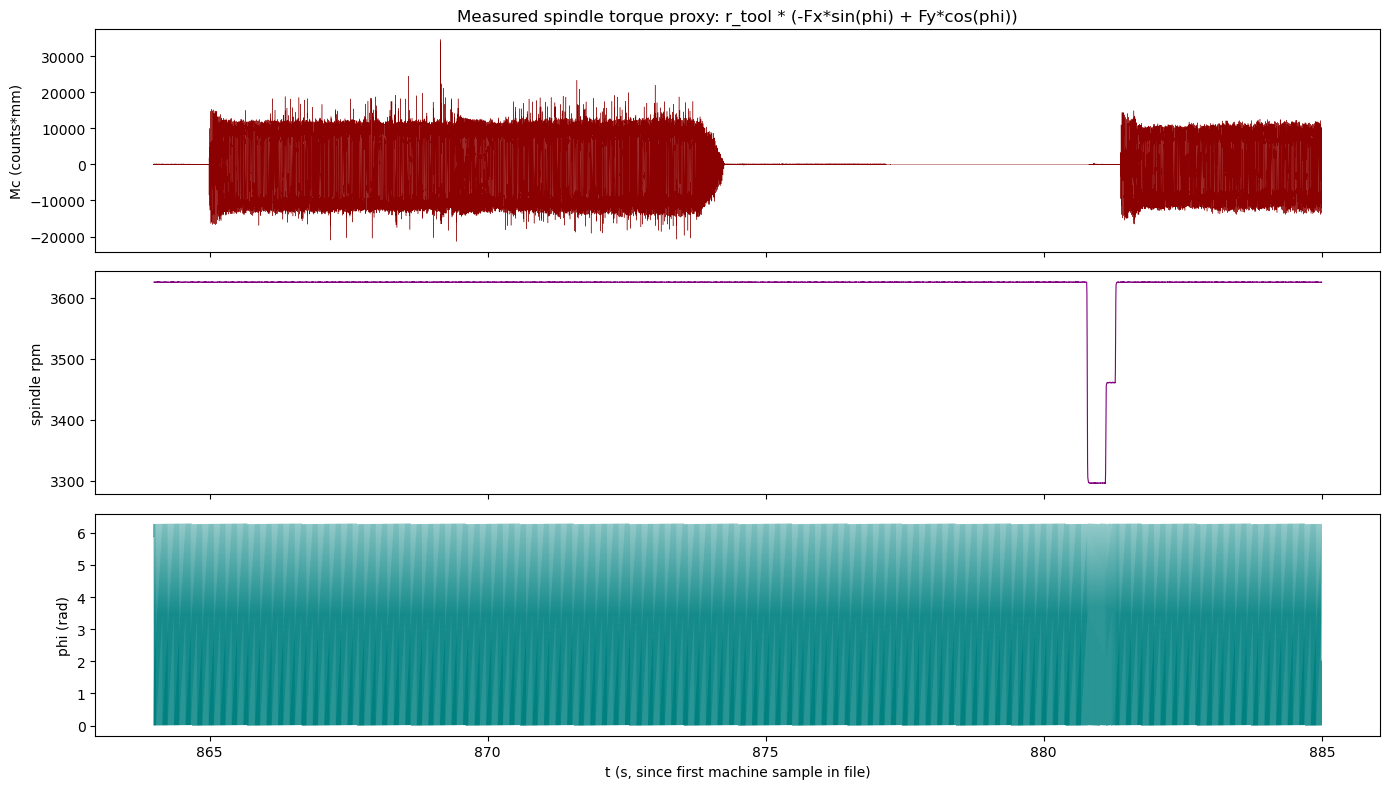

saved spindle_torque_qa.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(common_t, Mc, lw=0.3, color="darkred")
axes[0].set_ylabel("Mc (counts*mm)")
axes[0].set_title("Measured spindle torque proxy: r_tool * (-Fx*sin(phi) + Fy*cos(phi))")
axes[1].plot(window["t_s"], window["axis0_speedorfeedact"], lw=0.8, color="purple")
axes[1].set_ylabel("spindle rpm")
axes[2].plot(common_t, phi, lw=0.3, color="teal")
axes[2].set_ylabel("phi (rad)")
axes[2].set_xlabel("t (s, since first machine sample in file)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spindle_torque_qa.png", dpi=110)
plt.show()
print("saved spindle_torque_qa.png")

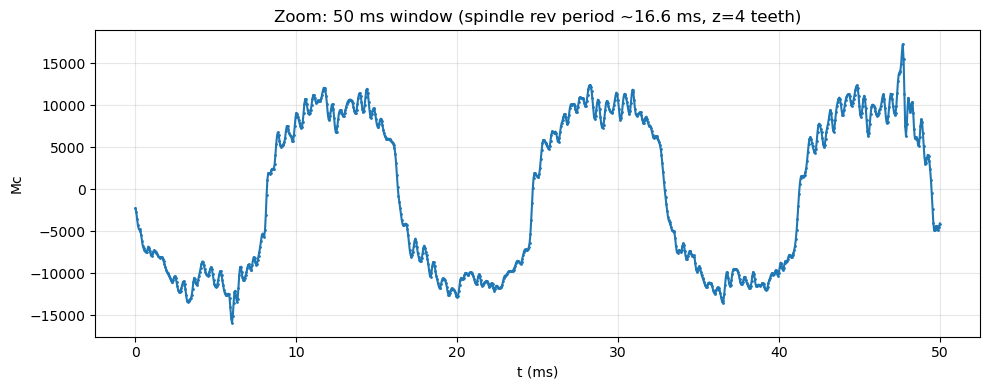

saved spindle_torque_qa_zoom.png


In [8]:
rev_period_ms = 60_000.0 / window["axis0_speedorfeedact"].abs().mean()
t_zoom0 = common_t[len(common_t) // 3]
zoom_mask = (common_t >= t_zoom0) & (common_t < t_zoom0 + 0.05)

plt.figure(figsize=(10, 4))
plt.plot((common_t[zoom_mask] - t_zoom0) * 1000, Mc[zoom_mask], ".-", ms=2)
plt.xlabel("t (ms)")
plt.ylabel("Mc")
plt.title(f"Zoom: 50 ms window (spindle rev period ~{rev_period_ms:.1f} ms, z={z_teeth:.0f} teeth)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spindle_torque_qa_zoom.png", dpi=110)
plt.show()
print("saved spindle_torque_qa_zoom.png")

## Notes / open items

- **`phi0_offset` is uncalibrated** (defaults to 0 in `spindle_torque`). It's the
  unknown phase between the encoder's zero and the force sensor's X axis. To
  calibrate, compare the angle of peak `|Mc|` per revolution against the known
  tool-engagement window once a fresh (non-stale) cut/NC-event log exists for this
  recording — the same way `MSU.max_Mc`/`lim_2pi` are used for the simulated model.
- **Units**: `force_0`/`force_1` are raw ADC counts, not newtons — there is no
  counts-to-newtons calibration anywhere in this repo yet, so `Mc` above is in
  `counts*mm`, not `N*mm`. Apply a calibration factor before treating it as a
  physical torque.
- **Gaps**: `phi_from_encoder` should only be called within a contiguous run of
  machine samples (see `largest_contiguous_run` above) — interpolating across a
  real multi-second logging gap produces a meaningless smeared angle there. A
  full-recording pipeline should chunk by contiguous run (e.g. per cut) rather than
  calling it once over the whole file.
- **Stale outputs in this folder**: `lev008_ALU_y_cut_summary_tagged.parquet` and
  `nc_command_log_lev008_ALU_y.parquet` under `data/converted/20260701_ALU_x/` are
  leftovers from a copy-pasted notebook that reused the *old* `20260630` cut
  segmentation without recomputing it for this file (their `cut_start` timestamps
  are literally `2026-06-30`). Re-run the cut/process-segmentation + NC-log cells
  from `axon_logger_lev008_process_cut_segmentation.ipynb` /
  `axon_logger_lev008_ALU_y_segmentation_and_nc_log.ipynb` against this file's own
  data before relying on cut windows here.